# **Final Evaluation — Brain Tumor Detection & Segmentation**

## **Imports & Configuration**

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras.models import load_model

## **Load Final Trained Models**

In [2]:
# Paths to the final trained models
classification_model_path = "brain_tumor_classifier.keras"
segmentation_model_path = "brain_tumor_segmenter.keras"

# Load models
classification_model = load_model(
    classification_model_path,
    compile=False
)

segmentation_model = load_model(
    segmentation_model_path,
    compile=False
)

print("Classification model loaded successfully.")
print("Segmentation model loaded successfully.")

Classification model loaded successfully.
Segmentation model loaded successfully.


## **Classification Class Labels**

In [3]:
class_names = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]

## **MRI Preprocessing**

In [4]:
def preprocess_mri(image_path):
    """
    Preprocess an MRI image for model inference.

    Returns:
        original_image: Grayscale MRI before resizing
        processed_image: Preprocessed image ready for the model
    """

    # Read image
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize to model input size
    resized = cv2.resize(
        gray,
        (224, 224),
        interpolation=cv2.INTER_AREA
    )

    # Normalize pixel values
    normalized = resized.astype(np.float32) / 255.0

    # Add channel dimension: (224, 224) → (224, 224, 1)
    processed = np.expand_dims(normalized, axis=-1)

    # Add batch dimension: (224, 224, 1) → (1, 224, 224, 1)
    processed = np.expand_dims(processed, axis=0)

    return gray, processed

## **End-to-End Inference Function**

In [19]:
def run_segmentation(processed_image):

    # -----------------------------
    # 1. Segmentation prediction
    # -----------------------------
    segmentation_probability = segmentation_model.predict(
        processed_image,
        verbose=0
    )[0, :, :, 0]

    # -----------------------------
    # 2. Convert probability map
    #    to binary mask
    # -----------------------------
    segmentation_mask = (
        segmentation_probability >= 0.5
    ).astype(np.uint8)

    return {
        "probability": segmentation_probability,
        "mask": segmentation_mask
    }

In [21]:
def run_inference(image_path):

    # -----------------------------
    # 1. Preprocessing
    # -----------------------------
    original_image, processed_image = preprocess_mri(image_path)

    # -----------------------------
    # 2. Classification
    # -----------------------------
    classification_prediction = classification_model.predict(
        processed_image,
        verbose=0
    )

    predicted_class_index = np.argmax(
        classification_prediction[0]
    )

    predicted_class = class_names[predicted_class_index]

    confidence = float(
        np.max(classification_prediction[0])
    )

    # -----------------------------
    # 3. Tumor / No Tumor decision
    # -----------------------------
    if predicted_class == "no_tumor":

        return {
            "image": original_image,
            "prediction": predicted_class,
            "confidence": confidence,
            "segmentation": None,
            "segmentation_probability": None
        }

    # -----------------------------
    # 4. Segmentation
    # -----------------------------
    segmentation_result = run_segmentation(
        processed_image
    )

    return {
        "image": original_image,
        "prediction": predicted_class,
        "confidence": confidence,
        "segmentation": segmentation_result["mask"],
        "segmentation_probability": segmentation_result["probability"]
    }

## **External Inference Images**

In [22]:
# Creating a temporary test image directory
import os
import shutil

TEST_DIR = "/content/test_images"

os.makedirs(TEST_DIR, exist_ok=True)

In [23]:
# Sending test images in test image directory from /content
for filename in os.listdir("/content"):

    if filename.lower().endswith((".jpg", ".jpeg", ".png")):

        shutil.move(
            os.path.join("/content", filename),
            os.path.join(TEST_DIR, filename)
        )

In [24]:
# Testing the directory
test_images = os.listdir(TEST_DIR)

print("Number of test images:", len(test_images))

for image in sorted(test_images):
    print(image)

Number of test images: 7
glioma1.jpg
glioma2.jpg
meningioma1.jpg
meningioma2.jpg
no_tumor1.jpg
no_tumor2.jpg
pituitary.jpg


In [25]:
test_image_paths = [
    os.path.join(TEST_DIR, filename)
    for filename in sorted(os.listdir(TEST_DIR))
    if filename.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total inference images:", len(test_image_paths))

Total inference images: 7


## **Classification Inference on External MRI Images**



In [36]:
result = run_inference(test_image_paths[0])

print("Prediction:", result["prediction"])
print("Confidence:", f"{result['confidence']:.2%}")

if result["segmentation"] is not None:
    print("Segmentation generated: Yes")
else:
    print("Segmentation generated: No")

Prediction: glioma
Confidence: 91.58%
Segmentation generated: Yes


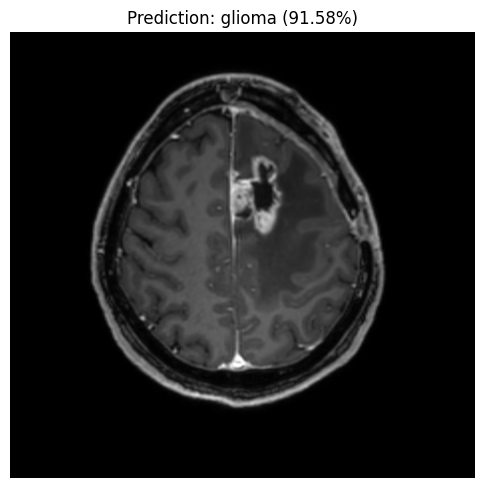

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.imshow(result["image"], cmap="gray")
plt.axis("off")

plt.title(
    f"Prediction: {result['prediction']} "
    f"({result['confidence']:.2%})"
)

plt.show()

## **Segmentation Inference on External MRI Images**

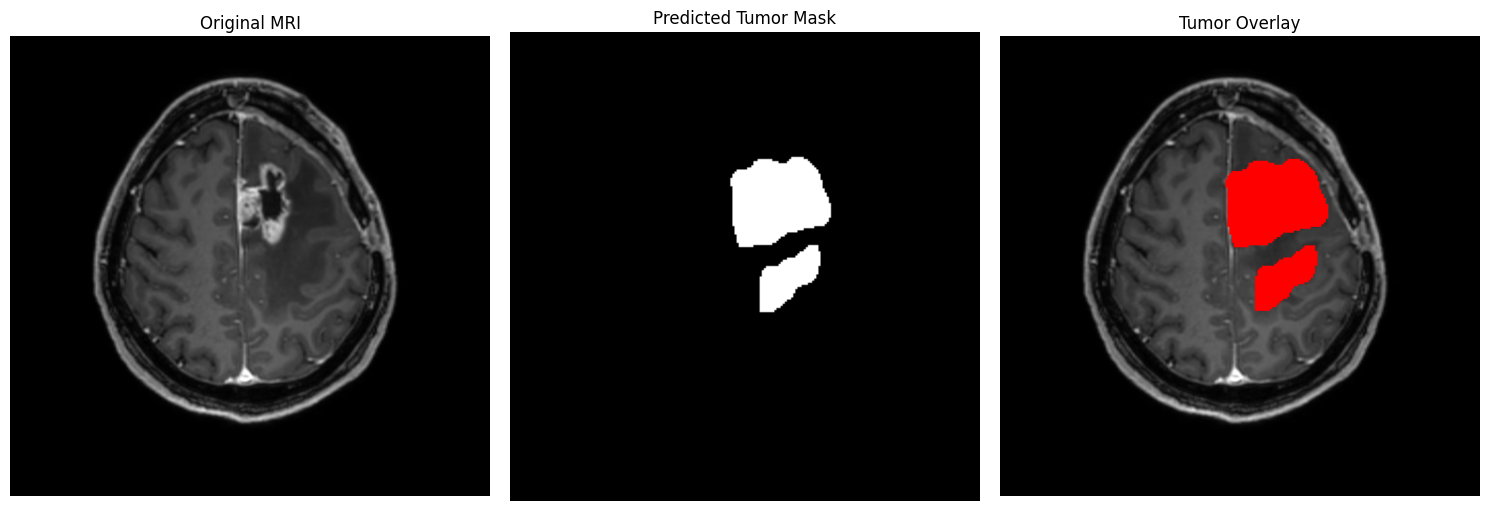

In [38]:
if result["segmentation"] is not None:

    original_image = result["image"]
    segmentation_mask = result["segmentation"]

    # Create tumor overlay
    overlay = original_image.copy()

    # Make sure image is RGB
    if len(overlay.shape) == 2:
        overlay = cv2.cvtColor(overlay, cv2.COLOR_GRAY2RGB)

    # Resize mask to original image size
    mask_resized = cv2.resize(
        segmentation_mask,
        (overlay.shape[1], overlay.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    # Apply mask overlay
    overlay[mask_resized == 1] = [255, 0, 0]

    # Display results
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original_image, cmap="gray")
    plt.title("Original MRI")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(segmentation_mask, cmap="gray")
    plt.title("Predicted Tumor Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Tumor Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

else:
    print("Segmentation was not generated because the model predicted No Tumor.")